In [6]:
from pathlib import Path
import os

# Run once
os.chdir(Path.cwd().parent)


In [ ]:
cwd = os.getcwd()
print(cwd)

/home/daniel/Documents/deepLearning/Project2_TrOCR


In [ ]:
import math
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms
from transformers import (
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)

from sklearn.model_selection import train_test_split
import torch.nn.functional as F



/home/daniel/Documents/deepLearning/Project2_TrOCR/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/daniel/Documents/deepLearning/Project2_TrOCR/.venv/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.2.0)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(


## to save encoder decoder weights

In [56]:

# Save

def save_components(model, save_dir):
    os.makedirs(save_dir, exist_ok=True)

    # Save encoder weights only
    encoder_state = {
        k: v for k, v in model.state_dict().items()
        if k.startswith("encoder")
    }
    torch.save(encoder_state, os.path.join(save_dir, "encoder.pt"))

    # Save decoder weights only 
    decoder_state = {
        k: v for k, v in model.state_dict().items()
        if not k.startswith("encoder")
    }
    torch.save(decoder_state, os.path.join(save_dir, "decoder.pt"))

    # Save full model too as a fallback
    torch.save(model.state_dict(), os.path.join(save_dir, "full_model.pt"))

    print(f"Saved encoder ({len(encoder_state)} tensors), "
          f"decoder ({len(decoder_state)} tensors), "
          f"full model to {save_dir}")





# Load

def load_components(model, save_dir, load_encoder=True, load_decoder=True, device="cpu"):
    if load_encoder:
        encoder_state = torch.load(
            os.path.join(save_dir, "encoder.pt"), map_location=device
        )
        missing, unexpected = model.load_state_dict(encoder_state, strict=False)
        bad_missing = [k for k in missing if k.startswith("encoder")]
        print(f"Encoder loaded — {len(encoder_state)} tensors, "
              f"problematic missing: {bad_missing}")

    if load_decoder:
        decoder_state = torch.load(
            os.path.join(save_dir, "decoder.pt"), map_location=device
        )
        missing, unexpected = model.load_state_dict(decoder_state, strict=False)
        bad_missing = [k for k in missing if not k.startswith("encoder")]
        print(f"Decoder loaded — {len(decoder_state)} tensors, "
              f"problematic missing: {bad_missing}")

    return model



## Model architecture + training pipeline

### Stage 1: SROIE DATASET pre train

In [ ]:
# prep dataset
def prepare_sroie(sroie_img_dir, sroie_ann_dir, output_img_dir, output_csv):
    os.makedirs(output_img_dir, exist_ok=True)
    records = []

    chars = set("ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789-/")

    for ann_file in os.listdir(sroie_ann_dir):
        if not ann_file.endswith(".txt"):
            continue

        img_name = ann_file.replace(".txt", ".jpg")
        img_path = os.path.join(sroie_img_dir, img_name)
        if not os.path.exists(img_path):
            continue

        img = Image.open(img_path).convert("RGB")

        with open(os.path.join(sroie_ann_dir, ann_file), "r", encoding="utf-8", errors="ignore") as f:
            for i, line in enumerate(f):
                line = line.strip()
                if not line:
                    continue

                parts = line.split(",")
                if len(parts) < 9:
                    continue

                # SROIE format: x1,y1,x2,y2,x3,y3,x4,y4,transcription
                try:
                    coords = list(map(int, parts[:8]))
                    text = ",".join(parts[8:]).strip().upper()
                except:
                    continue

                # Filter to your charset
                if not text or not all(c in chars for c in text):
                    continue

                # Filter to your max length
                if len(text) > 9 or len(text) < 2:
                    continue

                # Crop bounding box 
                xs = coords[0::2]
                ys = coords[1::2]
                x1, y1 = max(0, min(xs)), max(0, min(ys))
                x2, y2 = min(img.width, max(xs)), min(img.height, max(ys))

                if x2 <= x1 or y2 <= y1:
                    continue

                crop = img.crop((x1, y1, x2, y2))

                crop_name = f"sroie_{ann_file[:-4]}_{i:04d}.jpg"
                crop.save(os.path.join(output_img_dir, crop_name))

                records.append({
                    "image_name": crop_name,
                    "annotated_transcription": text
                })

    df = pd.DataFrame(records)
    print(f"Total crops: {len(df)}")
    print(f"Unique labels: {df['annotated_transcription'].nunique()}")
    df.to_csv(output_csv, index=False)
    return df

df = prepare_sroie(
    sroie_img_dir="archive (1)/SROIE2019/train/img",
    sroie_ann_dir="archive (1)/SROIE2019/train/box",
    output_img_dir="sroie_crops",
    output_csv="sroie_train.csv"
)



train_df, val_df = train_test_split(df, test_size=0.1, random_state=42)
train_df.to_csv("sroie_train.csv", index=False)
val_df.to_csv("sroie_val.csv", index=False)

Total crops: 7933
Unique labels: 1254


In [ ]:
# configs for tokenizer and dataset paths

chars      = "ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789-/"
PAD_ID     = 0
SOS_ID     = 1
EOS_ID     = 2
char2id    = {c: i + 3 for i, c in enumerate(chars)}
id2char    = {i + 3: c for i, c in enumerate(chars)}
VOCAB_SIZE = len(chars) + 3
MAX_LEN    = 9

TRAIN_CSV = "sroie_train.csv"
VAL_CSV   = "sroie_val.csv"
IMG_DIR   = "sroie_crops"


# handle character set tokenization

class CharTokenizer:
    def encode(self, text):
        return [char2id[c] for c in text if c in char2id]

    def decode(self, ids):
        out = []
        for i in ids:
            if i == EOS_ID:
                break
            if i in id2char:
                out.append(id2char[i])
        return "".join(out)


# augmentation and transforms for image preprocessing and training
train_augment = transforms.Compose([
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.015, hue=0.025),
    transforms.RandomAffine(degrees=3, translate=(0.015, 0.015), scale=(0.95, 1.05), shear=2),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.8)),
    transforms.RandomAutocontrast(p=0.1),
])

base_transform = transforms.Compose([
    transforms.Resize((64, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
])


# dataloader class for OCR dataset
class OCRDataset(Dataset):
    def __init__(self, csv_file, img_dir, tokenizer, max_length=MAX_LEN, augment=False, split = ""):
        self.df = pd.read_csv(csv_file)
        self.df = self.df[self.df["annotated_transcription"].notna()].reset_index(drop=True)
        self.img_dir = img_dir
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.augment = augment
        self.split = split
        self.df["relative_path"] = self.df["image_name"]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(os.path.join(self.img_dir, row["relative_path"])).convert("RGB")
        if self.augment:
            image = train_augment(image)

        pixel_values = base_transform(image)

        ids = self.tokenizer.encode(str(row["annotated_transcription"]))[:self.max_length]
        decoder_input = torch.tensor([SOS_ID] + ids, dtype=torch.long)
        labels = torch.tensor(ids + [EOS_ID], dtype=torch.long)

        return {
            "pixel_values": pixel_values,
            "decoder_input": decoder_input,
            "labels": labels,
        }


# collator function to handle padding of variable-length decoder inputs and labels in the dataloader
def ocr_collate_fn(batch):
    pixel_values = torch.stack([b["pixel_values"] for b in batch])

    max_tgt = max(b["decoder_input"].size(0) for b in batch)
    dec_inputs, label_list = [], []

    for b in batch:
        pad = max_tgt - b["decoder_input"].size(0)
        #pad inputs
        dec_inputs.append(torch.cat([
            b["decoder_input"],
            torch.full((pad,), PAD_ID, dtype=torch.long)
        ]))
        #pad labels
        label_list.append(torch.cat([
            b["labels"],
            torch.full((pad,), -100, dtype=torch.long)
        ]))

    return {
        "pixel_values": pixel_values,
        "decoder_input": torch.stack(dec_inputs),
        "labels": torch.stack(label_list),
    }


# class to handle sinusoidal positional encoding
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=64, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)

        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])



# CRNN module
class OCRCNNEncoder(nn.Module):
    def __init__(self, d_model=384):
        super().__init__()

        self.cnn = nn.Sequential(
            # input is (B, 3, 64, 256)
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),   #(B, 64, 32, 128)

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),   #(B, 128, 16, 64)

            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True), # (B, 256, 16, 64)

            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True), 
            nn.MaxPool2d(kernel_size=(2, 1), stride=(2, 1)),  # (B, 256, 8, 64)

            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True), # (B, 256, 8, 64)
            nn.MaxPool2d(kernel_size=(2, 1), stride=(2, 1)),  # (B, 256, 4, 64)
        )

        self.bilstm = nn.LSTM(
            input_size=256,
            hidden_size=256,
            num_layers=2,
            bidirectional=True,
            batch_first=True
        )

        self.proj = nn.Linear(512, d_model)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        x = self.cnn(x)            # (B, 256, 4, 64)
        x = x.mean(dim=2)          # collapse height to 1-d (B, 256, 64)
        x = x.permute(0, 2, 1)     # (B, 64, 256)

        x, _ = self.bilstm(x)      # (B, 64, 512)
        x = self.proj(x)           # (B, 64, d_model)
        x = self.norm(x)

        return x


# Combined model class that integrates the CNN encoder and Transformer decoder for OCR
class Seq2SeqOCR(nn.Module):
    def __init__(
        self,
        vocab_size=VOCAB_SIZE,
        d_model=384,
        nhead=8,
        num_dec_layers=3,
        dim_feedforward=768,
        dropout=0.3,
    ):
        super().__init__()

        # OCR CRNN encoder
        self.encoder = OCRCNNEncoder(d_model=d_model)
        self.enc_proj = nn.Identity()  

        # Seq to Seq Decoder
        self.tok_embed = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.pos_enc = PositionalEncoding(d_model, dropout=dropout)

        dec_layer = nn.TransformerDecoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
        )
        self.decoder = nn.TransformerDecoder(dec_layer, num_layers=num_dec_layers)
        self.out_proj = nn.Linear(d_model, vocab_size)

        self.criterion = nn.CrossEntropyLoss(ignore_index=-100, label_smoothing=0.10)

        total = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"Total params:     {total:,}")
        print(f"Trainable params: {trainable:,}  ({100*trainable/total:.1f}%)")

    def encode_image(self, pixel_values):
        return self.encoder(pixel_values)

    def forward(self, pixel_values, decoder_input, labels=None):
        memory = self.encode_image(pixel_values) #returns crnn output (B, 64, d_model = 384)

        tgt_len = decoder_input.size(1) #length of decoder input sequence
        tgt_mask = nn.Transformer.generate_square_subsequent_mask( #causal mask to prevent attending to future tokens
            tgt_len, device=pixel_values.device
        ) 
        tgt_key_padding_mask = (decoder_input == PAD_ID) #boolean mask to prevent attending to padding tokens

        tgt = self.pos_enc(self.tok_embed(decoder_input)) #token embedding + positional encoding for decoder input

        out = self.decoder( #transformer decoder that attends to encoder output (memory) and processes the target sequence (tgt) with appropriate masks
            tgt=tgt,
            memory=memory,
            tgt_mask=tgt_mask,
            tgt_key_padding_mask=tgt_key_padding_mask,
        )

        logits = self.out_proj(out) #generate scores per token

        loss = None
        if labels is not None: #compute loss by comparing logits to labels
            loss = self.criterion(
                logits.reshape(-1, logits.size(-1)),
                labels.reshape(-1)
            )

        return {"loss": loss, "logits": logits}


# Inference methods for greedy and beam search decoding
    @torch.no_grad()
    def greedy_decode(self, pixel_values, max_len=MAX_LEN):
        self.eval()
        memory = self.encode_image(pixel_values) #returns crnn output (B, 64, d_model = 384)
        dec_input = torch.tensor([[SOS_ID]], device=pixel_values.device) #init with sos token

        for _ in range(max_len): #autoregressive decoding loop
            tgt_mask = nn.Transformer.generate_square_subsequent_mask(
                dec_input.size(1), device=pixel_values.device
            )
            tgt = self.pos_enc(self.tok_embed(dec_input))
            out = self.decoder(tgt=tgt, memory=memory, tgt_mask=tgt_mask)
            next_tok = self.out_proj(out[:, -1, :]).argmax(-1, keepdim=True) #choose token with highest score as next token (greedy)

            if next_tok.item() == EOS_ID:
                break

            dec_input = torch.cat([dec_input, next_tok], dim=1)

        ids = dec_input[0, 1:].tolist()
        return "".join(id2char[i] for i in ids if i in id2char) #returns characters

    @torch.no_grad()
    def beam_decode(self, pixel_values, beam_width=5, max_len=MAX_LEN):
        self.eval()
        memory = self.encode_image(pixel_values)
        beams = [(0.0, [SOS_ID])] #init beams
        completed = []

        for _ in range(max_len):
            candidates = []

            for score, ids in beams:
                if ids[-1] == EOS_ID:
                    completed.append((score, ids))
                    continue

                dec_input = torch.tensor([ids], device=pixel_values.device)
                tgt_mask = nn.Transformer.generate_square_subsequent_mask(
                    len(ids), device=pixel_values.device
                )
                tgt = self.pos_enc(self.tok_embed(dec_input))
                out = self.decoder(tgt=tgt, memory=memory, tgt_mask=tgt_mask)
                log_prob = self.out_proj(out[:, -1, :]).log_softmax(-1)[0]
                topk = log_prob.topk(beam_width)

                for lp, tok in zip(topk.values, topk.indices):
                    candidates.append((score + lp.item(), ids + [tok.item()]))

            if not candidates:
                break

            beams = sorted(candidates, key=lambda x: x[0], reverse=True)[:beam_width]

            if all(b[1][-1] == EOS_ID for b in beams):
                completed.extend(beams)
                break

        if not completed:
            completed = beams

        best = max(completed, key=lambda x: x[0])[1]
        ids = [i for i in best[1:] if i != EOS_ID]
        return "".join(id2char[i] for i in ids if i in id2char)


# Custom Trainer class to handle training loop and compute loss for the OCR model, with added logging of learning rate every 50 steps
class OCRTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        if self.state.global_step % 50 == 0:
            print(f"Step {self.state.global_step} LR: {self.optimizer.param_groups[0]['lr']:.2e}")
    
        outputs = model(
            pixel_values=inputs["pixel_values"],
            decoder_input=inputs["decoder_input"],
            labels=inputs["labels"],
        )
        loss = outputs["loss"]
        return (loss, outputs) if return_outputs else loss
    


# training setup
device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = CharTokenizer()

train_dataset = OCRDataset(TRAIN_CSV, IMG_DIR, tokenizer, augment=False, split="")
val_dataset = OCRDataset(VAL_CSV, IMG_DIR, tokenizer, augment=False, split="")

model = Seq2SeqOCR().to(device)

device = "cuda" if torch.cuda.is_available() else "cpu"



# HF trainer setup with early stopping
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=150,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    learning_rate=1e-4,
    lr_scheduler_type="linear",
    weight_decay=0.05,
    warmup_steps=20,
    logging_steps=10,
    save_strategy="epoch",
    eval_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    remove_unused_columns=False,
    fp16=False
)

trainer = OCRTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=ocr_collate_fn,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=15,
            early_stopping_threshold=0.001,
        )
    ],
)

trainer.train()


# save encoder and decoder weights
save_components(model, "./stage1_synthetic")



Total params:     9,737,897
Trainable params: 9,737,897  (100.0%)
Step 0 LR: 0.00e+00


/home/daniel/Documents/deepLearning/Project2_TrOCR/.venv/lib/python3.12/site-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


Epoch,Training Loss,Validation Loss
1,1.954912,1.968885
2,1.771195,1.789895
3,1.605682,1.691442
4,1.510974,1.535015
5,1.290164,1.349934
6,1.177612,1.227004
7,1.060122,1.139655
8,0.991360,1.053522
9,0.937641,0.974328
10,0.908781,0.939320


Step 50 LR: 9.99e-05
Step 100 LR: 9.98e-05
Step 150 LR: 9.96e-05
Step 200 LR: 9.95e-05


/home/daniel/Documents/deepLearning/Project2_TrOCR/.venv/lib/python3.12/site-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(
/home/daniel/Documents/deepLearning/Project2_TrOCR/.venv/lib/python3.12/site-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


...

Step 11900 LR: 6.46e-05
Step 11950 LR: 6.45e-05
Step 12000 LR: 6.43e-05
Step 12050 LR: 6.42e-05


/home/daniel/Documents/deepLearning/Project2_TrOCR/.venv/lib/python3.12/site-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


Step 12100 LR: 6.40e-05
Step 12150 LR: 6.39e-05
Step 12200 LR: 6.37e-05
Step 12250 LR: 6.36e-05
Step 12300 LR: 6.34e-05


/home/daniel/Documents/deepLearning/Project2_TrOCR/.venv/lib/python3.12/site-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


Step 12350 LR: 6.33e-05
Step 12400 LR: 6.31e-05
Step 12450 LR: 6.30e-05
Step 12500 LR: 6.28e-05
Saved encoder (30 tensors), decoder (58 tensors), full model to ./stage1_synthetic


### Stage 2: Personal Dataset fine tune

In [ ]:
# configs for tokenizer and dataset paths 
chars      = "ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789-/"
PAD_ID     = 0
SOS_ID     = 1
EOS_ID     = 2
char2id    = {c: i + 3 for i, c in enumerate(chars)}
id2char    = {i + 3: c for i, c in enumerate(chars)}
VOCAB_SIZE = len(chars) + 3
MAX_LEN    = 9

TRAIN_CSV = "data/OCRcropsv3/train/tradOutputTrain/annotatedTrainV3.csv"
VAL_CSV   = "data/OCRcropsv3/val/tradOutputVal/annotatedValV3.csv"
IMG_DIR   = "data/OCRcropsv3"

# handle character set tokenization 
class CharTokenizer:
    def encode(self, text):
        return [char2id[c] for c in text if c in char2id]

    def decode(self, ids):
        out = []
        for i in ids:
            if i == EOS_ID:
                break
            if i in id2char:
                out.append(id2char[i])
        return "".join(out)

# augmentation and transforms for image preprocessing and training 
train_augment = transforms.Compose([
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.05, hue=0.03),
    transforms.RandomAffine(degrees=5, translate=(0.03, 0.03), scale=(0.92, 1.08), shear=3),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),
    transforms.RandomAutocontrast(p=0.2),
])


base_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.rotate(90, expand=True)),
    transforms.Resize((64, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
])


# dataloader class for OCR dataset 
class OCRDataset(Dataset):
    def __init__(self, csv_file, img_dir, tokenizer, max_length=MAX_LEN, augment=False, split = "train/"):
        self.df = pd.read_csv(csv_file)
        self.df = self.df[self.df["annotated_transcription"].notna()].reset_index(drop=True)
        self.img_dir = img_dir
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.augment = augment
        self.split = split
        self.df["relative_path"] = self.df["image"].str.replace(r".*\?d=[^/]+/", "", regex=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(os.path.join(self.img_dir, self.split, row["relative_path"])).convert("RGB")
        if self.augment:
            image = train_augment(image)

        pixel_values = base_transform(image)

        ids = self.tokenizer.encode(str(row["annotated_transcription"]))[:self.max_length]
        decoder_input = torch.tensor([SOS_ID] + ids, dtype=torch.long)
        labels = torch.tensor(ids + [EOS_ID], dtype=torch.long)

        return {
            "pixel_values": pixel_values,
            "decoder_input": decoder_input,
            "labels": labels,
        }

 

# collator function to handle padding of variable-length decoder inputs and labels in the dataloader 
def ocr_collate_fn(batch):
    pixel_values = torch.stack([b["pixel_values"] for b in batch])

    max_tgt = max(b["decoder_input"].size(0) for b in batch)
    dec_inputs, label_list = [], []

    for b in batch:
        pad = max_tgt - b["decoder_input"].size(0)
        dec_inputs.append(torch.cat([
            b["decoder_input"],
            torch.full((pad,), PAD_ID, dtype=torch.long)
        ]))
        label_list.append(torch.cat([
            b["labels"],
            torch.full((pad,), -100, dtype=torch.long)
        ]))

    return {
        "pixel_values": pixel_values,
        "decoder_input": torch.stack(dec_inputs),
        "labels": torch.stack(label_list),
    }


# class to handle sinusoidal positional encoding 
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=64, dropout=0.2):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)

        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])
    

# CRNN module 
class OCRCNNEncoder(nn.Module):
    def __init__(self, d_model=384):
        super().__init__()

        self.cnn = nn.Sequential(
            # input is (B, 3, 64, 256) 
            nn.Conv2d(3, 64, 3, 1, 1),   
            nn.ReLU(inplace=True),       
            nn.MaxPool2d(2, 2), #(B, 64, 32, 128)       

            nn.Conv2d(64, 128, 3, 1, 1), 
            nn.ReLU(inplace=True),       
            nn.MaxPool2d(2, 2), #(B, 128, 16, 64)          

            nn.Conv2d(128, 256, 3, 1, 1),
            nn.ReLU(inplace=True),  #(B, 256, 16, 64)       

            nn.Conv2d(256, 256, 3, 1, 1),
            nn.ReLU(inplace=True),       
            nn.MaxPool2d((2,1), (2,1)), # (B, 256, 8, 64)  

            nn.Conv2d(256, 256, 3, 1, 1),
            nn.ReLU(inplace=True),       
            nn.MaxPool2d((2,1), (2,1)), # (B, 256, 4, 64) 
        )

        self.bilstm = nn.LSTM(
            input_size=256,
            hidden_size=256,
            num_layers=2,
            bidirectional=True,
            batch_first=True,
            dropout=0.2
        )
        self.proj = nn.Linear(512, d_model)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        x = self.cnn(x) # (B, 256, 4, 64) 

        # Add dropout
        x = F.dropout2d(x, p=0.1, training=self.training)

        x = x.mean(dim=2) # collapse height to 1-d (B, 256, 64)
        x = x.permute(0, 2, 1) # (B, 64, 256) 

        x, _ = self.bilstm(x)  # (B, 64, 512) 

        # Add dropout after BiLSTM
        x = F.dropout(x, p=0.2, training=self.training)

        x = self.proj(x) #(B, 64, d_model)
        x = self.norm(x)

        return x

# Combined model class that integrates the CNN encoder and Transformer decoder for OCR 
class Seq2SeqOCR(nn.Module):
    def __init__(
        self,
        vocab_size=VOCAB_SIZE,
        d_model=384,
        nhead=8,
        num_dec_layers=2,
        dim_feedforward=768,
        dropout=0.3,
    ):
        super().__init__()

        # OCR CRNN encoder 
        self.encoder = OCRCNNEncoder(d_model=d_model)
        self.enc_proj = nn.Identity()  

        # Seq to Seq Decoder
        self.tok_embed = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.pos_enc = PositionalEncoding(d_model, dropout=dropout)

        dec_layer = nn.TransformerDecoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
        )
        self.decoder = nn.TransformerDecoder(dec_layer, num_layers=num_dec_layers)
        self.out_proj = nn.Linear(d_model, vocab_size)

        self.criterion = nn.CrossEntropyLoss(ignore_index=-100, label_smoothing=0.15)

        total = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"Total params:     {total:,}")
        print(f"Trainable params: {trainable:,}  ({100*trainable/total:.1f}%)")

    def encode_image(self, pixel_values):
        return self.encoder(pixel_values)

    def forward(self, pixel_values, decoder_input, labels=None):
        memory = self.encode_image(pixel_values) #returns crnn output (B, 64, d_model = 384) 


        tgt_len = decoder_input.size(1) #length of decoder input sequence
        #causal mask to prevent attending to future tokens 
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(
            tgt_len, device=pixel_values.device
        )
        tgt_key_padding_mask = (decoder_input == PAD_ID) #boolean mask to prevent attending to padding tokens 

        tgt = self.pos_enc(self.tok_embed(decoder_input)) #token embedding + positional encoding for decoder input 

        #transformer decoder that attends to encoder output (memory) and processes the target sequence (tgt) with appropriate masks 
        out = self.decoder(
            tgt=tgt,
            memory=memory,
            tgt_mask=tgt_mask,
            tgt_key_padding_mask=tgt_key_padding_mask,
        )

        logits = self.out_proj(out) #generate scores per token 

        loss = None
        if labels is not None:
            #compute loss by comparing logits to labels
            loss = self.criterion(
                logits.reshape(-1, logits.size(-1)),
                labels.reshape(-1)
            )

        return {"loss": loss, "logits": logits}


# Inference methods for greedy and beam search decoding 
    @torch.no_grad()
    def greedy_decode(self, pixel_values, max_len=MAX_LEN):
        self.eval()
        memory = self.encode_image(pixel_values) #returns crnn output (B, 64, d_model = 384) 
        dec_input = torch.tensor([[SOS_ID]], device=pixel_values.device) #init with sos token 

        for _ in range(max_len): #autoregressive decoding loop
            tgt_mask = nn.Transformer.generate_square_subsequent_mask(
                dec_input.size(1), device=pixel_values.device
            )
            tgt = self.pos_enc(self.tok_embed(dec_input))
            out = self.decoder(tgt=tgt, memory=memory, tgt_mask=tgt_mask)
            next_tok = self.out_proj(out[:, -1, :]).argmax(-1, keepdim=True) #choose token with highest score as next token (greedy) 

            if next_tok.item() == EOS_ID:
                break

            dec_input = torch.cat([dec_input, next_tok], dim=1)

        ids = dec_input[0, 1:].tolist()
        return "".join(id2char[i] for i in ids if i in id2char) #returns characters 

    @torch.no_grad()
    def beam_decode(self, pixel_values, beam_width=5, max_len=MAX_LEN):
        self.eval()
        memory = self.encode_image(pixel_values)
        beams = [(0.0, [SOS_ID])] #init beams
        completed = []

        for _ in range(max_len):
            candidates = []

            for score, ids in beams:
                if ids[-1] == EOS_ID:
                    completed.append((score, ids))
                    continue

                dec_input = torch.tensor([ids], device=pixel_values.device)
                tgt_mask = nn.Transformer.generate_square_subsequent_mask(
                    len(ids), device=pixel_values.device
                )
                tgt = self.pos_enc(self.tok_embed(dec_input))
                out = self.decoder(tgt=tgt, memory=memory, tgt_mask=tgt_mask)
                log_prob = self.out_proj(out[:, -1, :]).log_softmax(-1)[0]
                topk = log_prob.topk(beam_width)

                for lp, tok in zip(topk.values, topk.indices):
                    candidates.append((score + lp.item(), ids + [tok.item()]))

            if not candidates:
                break

            beams = sorted(candidates, key=lambda x: x[0], reverse=True)[:beam_width]

            if all(b[1][-1] == EOS_ID for b in beams):
                completed.extend(beams)
                break

        if not completed:
            completed = beams

        best = max(completed, key=lambda x: x[0])[1]
        ids = [i for i in best[1:] if i != EOS_ID]
        return "".join(id2char[i] for i in ids if i in id2char)


# Custom Trainer class to handle training loop and compute loss for the OCR model, with added logging of learning rate every 50 steps 
class OCRTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        outputs = model(
            pixel_values=inputs["pixel_values"],
            decoder_input=inputs["decoder_input"],
            labels=inputs["labels"],
        )
        loss = outputs["loss"]
        return (loss, outputs) if return_outputs else loss

    def create_optimizer(self):
        self.optimizer = torch.optim.AdamW(
            [
                {"params": self.model.encoder.parameters(), "lr": 1e-4},
                {"params": self.model.tok_embed.parameters(), "lr": 1e-4},
                {"params": self.model.decoder.parameters(), "lr": 1e-4},
                {"params": self.model.out_proj.parameters(), "lr": 1e-4},
            ],
            weight_decay=self.args.weight_decay,
        )
        return self.optimizer
    

# training setup 
device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = CharTokenizer()

train_dataset = OCRDataset(TRAIN_CSV, IMG_DIR, tokenizer, augment=True, split="train/")
val_dataset = OCRDataset(VAL_CSV, IMG_DIR, tokenizer, augment=False, split="val/")

# call to load in model weights
device = "cuda" if torch.cuda.is_available() else "cpu"

model = Seq2SeqOCR().to(device)
model = load_components(
    model,
    "./stage1_synthetic",
    load_encoder=True,
    load_decoder=True,
    device=device
)


# HF trainer setup with early stopping 
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=150,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=1e-4,
    lr_scheduler_type="linear",
    weight_decay=0.05,
    warmup_steps=150,
    logging_steps=10,
    save_strategy="epoch",
    eval_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    remove_unused_columns=False,
    fp16=torch.cuda.is_available(),
)

trainer = OCRTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=ocr_collate_fn,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=15,
            early_stopping_threshold=0.001,
        )
    ],
)

trainer.train()


model.eval()

test_df = pd.read_csv("/home/daniel/Documents/deepLearning/Project2_TrOCR/data/OCRcropsv3/test/tradOutputTest/annotatedTestV3.csv").dropna(subset=["annotated_transcription"])

test_dataset = OCRDataset("/home/daniel/Documents/deepLearning/Project2_TrOCR/data/OCRcropsv3/test/tradOutputTest/annotatedTestV3.csv", IMG_DIR, tokenizer, augment=False, split="test/")


greedy_correct = beam_correct = 0
total = len(test_dataset)

print(f"\n{'True':<14} {'Greedy':<14} {'Beam':<14}")
print("-" * 58)

for i in range(total):
    sample = test_dataset[i]
    pv     = sample["pixel_values"].unsqueeze(0).to(device)
    true   = test_df.iloc[i]["annotated_transcription"]

    greedy = model.greedy_decode(pv)
    beam   = model.beam_decode(pv, beam_width=10)

    gm = "✓" if greedy == true else "✗"
    bm = "✓" if beam   == true else "✗"

    if not (greedy == true and beam == true):
        print(f"{true:<14}  {gm} {greedy:<13} {bm} {beam:<13}")

    greedy_correct += int(greedy == true)
    beam_correct   += int(beam   == true)

print("-" * 58)
print(f"Greedy  exact match: {greedy_correct}/{total}  ({100*greedy_correct/total:.1f}%)")
print(f"Beam    exact match: {beam_correct}/{total}  ({100*beam_correct/total:.1f}%)")

Total params:     7,961,897
Trainable params: 7,961,897  (100.0%)
Encoder loaded — 30 tensors, problematic missing: []
Decoder loaded — 58 tensors, problematic missing: []


/home/daniel/Documents/deepLearning/Project2_TrOCR/.venv/lib/python3.12/site-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


Epoch,Training Loss,Validation Loss
1,2.744003,2.473664
2,2.251153,2.179068
3,2.101245,2.055524
4,2.016377,2.000634
5,1.981130,1.937999
6,1.945524,1.911771
7,1.883089,1.884875
8,1.898044,1.872081
9,1.850403,1.832958
10,1.814290,1.807759


/home/daniel/Documents/deepLearning/Project2_TrOCR/.venv/lib/python3.12/site-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(
/home/daniel/Documents/deepLearning/Project2_TrOCR/.venv/lib/python3.12/site-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(
/home/daniel/Documents/deepLearning/Project2_TrOCR/.venv/lib/python3.12/site-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(
/home/daniel/Documents/deepLearning/Project2_TrOCR/.venv/lib/python3.12/site-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_paddin


True           Greedy         Beam          
----------------------------------------------------------
5115            ✗ 5383          ✗ 5383         
57107           ✗ 5382          ✗ 5382         
55080           ✗ 31247DL       ✗ 31247DL      
54017           ✗ 44604         ✗ 44723        
55080           ✗ 31247DL       ✗ 31247DL      
31275DL         ✗ 31325DL       ✗ 31325DL      
31336           ✗ 53059         ✗ 53059        
72025DL         ✗ 31316DL       ✗ 31316DL      
60119DL         ✗ 42260         ✗ 42260        
31311DL         ✗ 44622DL       ✓ 31311DL      
76018DL         ✗ 31325DL       ✗ 31325DL      
44650DL         ✗ 72165DL       ✗ 72165DL      
31327DL         ✗ 55067DL       ✗ 55067DL      
5396            ✗ 53025         ✗ 53025        
45413           ✗ 31243         ✗ 31243        
44599           ✗ 44720         ✗ 44720        
5547            ✗ 42250         ✗ 42250        
31447DL         ✗ 44627DL       ✓ 31447DL      
31337           ✗ 31247DL      

In [84]:
save_components(model, "./final_model")


Saved encoder (30 tensors), decoder (40 tensors), full model to ./final_model


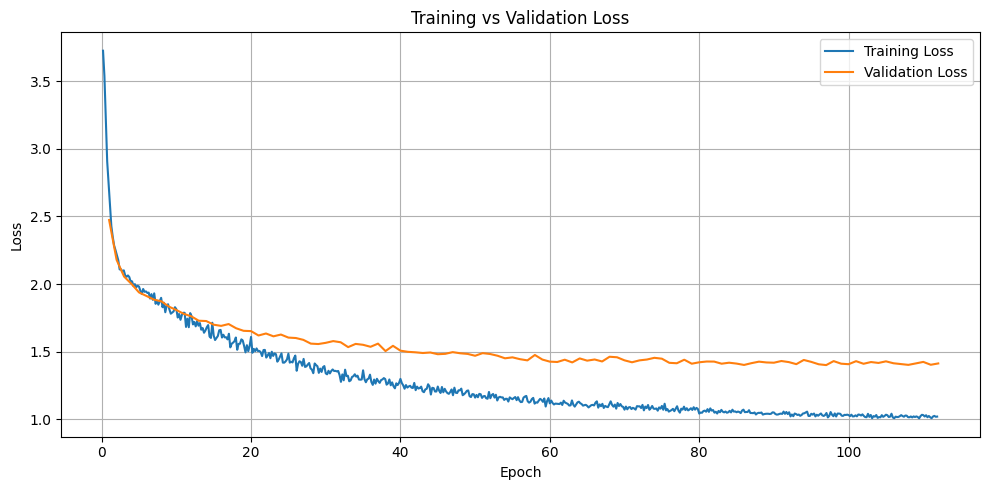

In [85]:
import matplotlib.pyplot as plt

logs = trainer.state.log_history

train_loss = [(l["epoch"], l["loss"]) for l in logs if "loss" in l and "eval_loss" not in l]
val_loss   = [(l["epoch"], l["eval_loss"]) for l in logs if "eval_loss" in l]

train_epochs, train_losses = zip(*train_loss)
val_epochs,   val_losses   = zip(*val_loss)

plt.figure(figsize=(10, 5))
plt.plot(train_epochs, train_losses, label="Training Loss")
plt.plot(val_epochs,   val_losses,   label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("loss_curve.png")
plt.show()

In [ ]:
modeleval = Seq2SeqOCR().to(device)
modeleval = load_components(
    modeleval,
    "./final_model",
    load_encoder=True,
    load_decoder=True,
    device=device
)

modeleval.eval()

test_df = pd.read_csv("/home/daniel/Documents/deepLearning/Project2_TrOCR/data/OCRcropsv3/test/tradOutputTest/annotatedTestV3.csv").dropna(subset=["annotated_transcription"])

test_dataset = OCRDataset("/home/daniel/Documents/deepLearning/Project2_TrOCR/data/OCRcropsv3/test/tradOutputTest/annotatedTestV3.csv", IMG_DIR, tokenizer, augment=False, split="test/")


greedy_correct = beam_correct = 0
total = len(test_dataset)

print(f"\n{'True':<14} {'Greedy':<14} {'Beam':<14}")
print("-" * 58)

results = []

for i in range(total):
    sample = test_dataset[i]
    pv     = sample["pixel_values"].unsqueeze(0).to(device)
    true   = test_df.iloc[i]["annotated_transcription"]

    greedy = modeleval.greedy_decode(pv)
    beam   = modeleval.beam_decode(pv, beam_width=10)

    results.append({
        "true": true,
        "greedy": greedy,
        "beam": beam,
        "image_name": test_df.iloc[i]["image"]
    })

    gm = "✓" if greedy == true else "✗"
    bm = "✓" if beam   == true else "✗"

    if not (greedy == true and beam == true):
        print(f"{true:<14}  {gm} {greedy:<13} {bm} {beam:<13}")

    greedy_correct += int(greedy == true)
    beam_correct   += int(beam   == true)

print("-" * 58)
print(f"Greedy  exact match: {greedy_correct}/{total}  ({100*greedy_correct/total:.1f}%)")
print(f"Beam    exact match: {beam_correct}/{total}  ({100*beam_correct/total:.1f}%)")

Total params:     7,961,897
Trainable params: 7,961,897  (100.0%)
Encoder loaded — 30 tensors, problematic missing: []
Decoder loaded — 40 tensors, problematic missing: []

True           Greedy         Beam          
----------------------------------------------------------
5115            ✗ 5383          ✗ 5383         
57107           ✗ 5382          ✗ 5382         
55080           ✗ 31247DL       ✗ 31247DL      
54017           ✗ 44604         ✗ 44723        
55080           ✗ 31247DL       ✗ 31247DL      
31275DL         ✗ 31325DL       ✗ 31325DL      
31336           ✗ 53059         ✗ 53059        
72025DL         ✗ 31316DL       ✗ 31316DL      
60119DL         ✗ 42260         ✗ 42260        
31311DL         ✗ 44622DL       ✓ 31311DL      
76018DL         ✗ 31325DL       ✗ 31325DL      
44650DL         ✗ 72165DL       ✗ 72165DL      
31327DL         ✗ 55067DL       ✗ 55067DL      
5396            ✗ 53025         ✗ 53025        
45413           ✗ 31243         ✗ 31243        
445

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
modeleval = Seq2SeqOCR().to(device)
modeleval = load_components(
    modeleval,
    "./final_model",
    load_encoder=True,
    load_decoder=True,
    device=device
)

modeleval.eval()

train_df = pd.read_csv("data/OCRcropsv3/train/tradOutputTrain/annotatedTrainV3.csv").dropna(subset=["annotated_transcription"])

train_dataset = OCRDataset("data/OCRcropsv3/train/tradOutputTrain/annotatedTrainV3.csv", IMG_DIR, tokenizer, augment=False, split="train/")

greedy_correct = beam_correct = 0
total = len(train_dataset)

print(f"\n{'True':<14} {'Greedy':<14} {'Beam':<14}")
print("-" * 58)

results = []

for i in range(total):
    sample = train_dataset[i]
    pv     = sample["pixel_values"].unsqueeze(0).to(device)
    true   = train_df.iloc[i]["annotated_transcription"]

    greedy = modeleval.greedy_decode(pv)
    beam   = modeleval.beam_decode(pv, beam_width=10)

    results.append({
        "true": true,
        "greedy": greedy,
        "beam": beam,
        "image_name": train_df.iloc[i]["image"]
    })

    gm = "✓" if greedy == true else "✗"
    bm = "✓" if beam   == true else "✗"

    if not (greedy == true and beam == true):
        print(f"{true:<14}  {gm} {greedy:<13} {bm} {beam:<13}")

    greedy_correct += int(greedy == true)
    beam_correct   += int(beam   == true)

print("-" * 58)
print(f"Greedy  exact match: {greedy_correct}/{total}  ({100*greedy_correct/total:.1f}%)")
print(f"Beam    exact match: {beam_correct}/{total}  ({100*beam_correct/total:.1f}%)")

Total params:     7,961,897
Trainable params: 7,961,897  (100.0%)
Encoder loaded — 30 tensors, problematic missing: []
Decoder loaded — 40 tensors, problematic missing: []

True           Greedy         Beam          
----------------------------------------------------------
74010DL         ✗ 75010DL       ✗ 75010DL      
75032DL         ✗ 75029DL       ✓ 75032DL      
5115            ✗ 5383          ✗ 5383         
75029DL         ✗ 42151DL       ✗ 42151DL      
77506DL         ✗ 75066DL       ✗ 75066DL      
44720           ✗ 54017         ✗ 54017        
----------------------------------------------------------
Greedy  exact match: 849/855  (99.3%)
Beam    exact match: 850/855  (99.4%)


In [98]:
import Levenshtein

class evaluation:
    ### functions for eval metrics, input = (gt, model output list) (ensure order)
    def __init__(self, groundTruth, results):
        self.gt = groundTruth
        self.pred = results

    def accuracy(self):
        correct = (self.gt == self.pred)
        return correct.mean() 

    def character_accuracy(self):
        total_chars = 0
        total_errors = 0

        for gt, pred in zip(self.gt, self.pred):
            gt = str(gt)
            pred = str(pred)

            dist = Levenshtein.distance(gt, pred)

            total_errors += dist
            total_chars += len(gt)

        return 1 - (total_errors / total_chars)

In [99]:
import pandas as pd

df_results = pd.DataFrame(results)

greedy_evaluation = evaluation(df_results["true"], df_results["greedy"])
beam_evaluation = evaluation(df_results["true"], df_results["beam"])

print(f"Greedy Word Accuracy: {greedy_evaluation.accuracy()}")
print(f"Greedy Character Accuracy: {greedy_evaluation.character_accuracy()}")


print(f"Beam Word Accuracy: {beam_evaluation.accuracy()}")
print(f"Beam Character Accuracy: {beam_evaluation.character_accuracy()}")


Greedy Word Accuracy: 0.6542056074766355
Greedy Character Accuracy: 0.7704918032786885
Beam Word Accuracy: 0.6822429906542056
Beam Character Accuracy: 0.7967213114754098


In [108]:
errors_df = df_results[df_results["true"] != df_results["beam"]]
sampled = errors_df.sample(n=10, random_state=7)

errors = sampled["image_name"]
numbers = sampled["true"]
error_numbers = sampled["beam"]

In [107]:
len(errors)

34

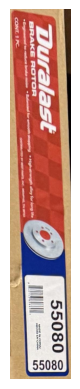

Ground Truth: 55080
Predicted: 31247DL


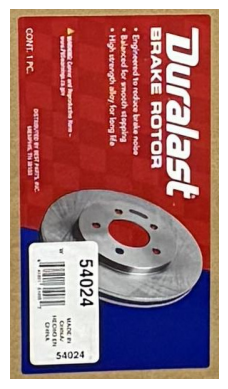

Ground Truth: 54024
Predicted: 54029


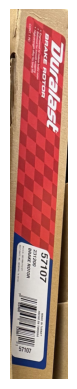

Ground Truth: 57107
Predicted: 5382


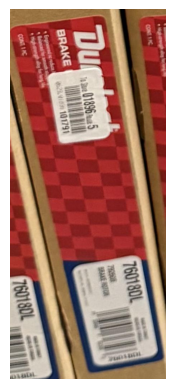

Ground Truth: 76018DL
Predicted: 31325DL


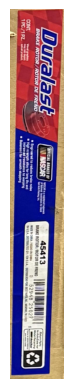

Ground Truth: 45413
Predicted: 31243


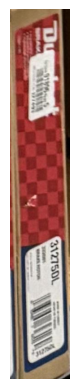

Ground Truth: 31275DL
Predicted: 31325DL


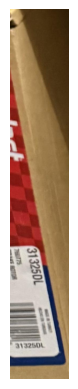

Ground Truth: 31325DL
Predicted: 31315DL


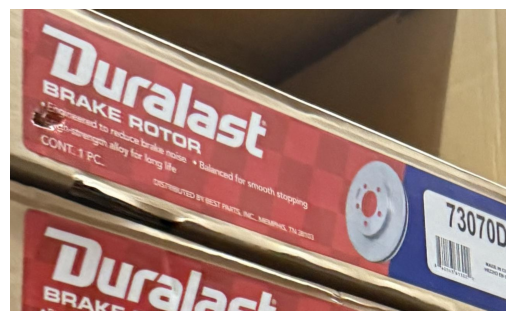

Ground Truth: 73070
Predicted: 73020DL


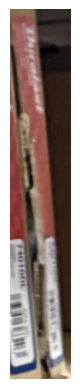

Ground Truth: 74010DL
Predicted: 72089DL


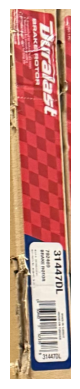

Ground Truth: 31447DL
Predicted: 44306DL


In [109]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import re

for error, number, error_number in zip(errors, numbers, error_numbers):
    cleaned_path = error.rsplit("/", 1)[-1]
    img = mpimg.imread("data/OCRcropsv3/test/rawCropTest/" + cleaned_path)  
    plt.imshow(img)
    plt.axis('off')  
    plt.show()
    print(f"Ground Truth: {number}")
    print(f"Predicted: {error_number}")